[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-12-7af4dadbe709>:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  '5-Year Return': np.log(series[-1] / series[0]) / 5 * 100 if len(series) > 0 else None,


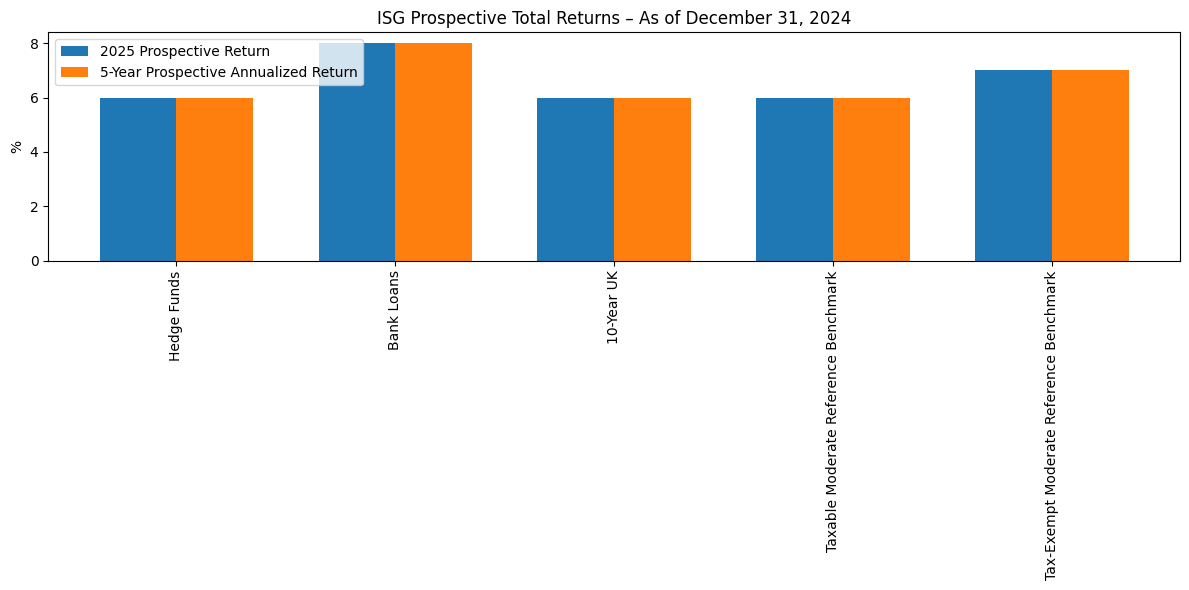

Cleaned ISG Prospective Returns:
                                         5-Year Prospective Annualized Return  \
Hedge Funds                                                               6.0   
Bank Loans                                                                8.0   
10-Year UK                                                                6.0   
Taxable Moderate Reference Benchmark                                      6.0   
Tax-Exempt Moderate Reference Benchmark                                   7.0   

                                         2025 Prospective Return  
Hedge Funds                                                  6.0  
Bank Loans                                                   8.0  
10-Year UK                                                   6.0  
Taxable Moderate Reference Benchmark                         6.0  
Tax-Exempt Moderate Reference Benchmark                      7.0  


In [12]:
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# FRED API key (replace with your own if necessary)
fred = Fred(api_key='e71171df83bca10e960eaa0422c8897d')

# Define the assets and their data sources
assets = {
    'DXY': {'source': 'yfinance', 'ticker': 'DX-Y.NYB'},
    #'Muni 1-10': {'source': 'fred', 'ticker': 'MUNIRATE'},
    'US Cash': {'source': 'fred', 'ticker': 'DFF'},
    'EM Local Debt': {'source': 'yfinance', 'ticker': 'EMB'},  # Example ETF for EM debt
    #'Muni HY': {'source': 'fred', 'ticker': 'MUNIHY'},
    'Hedge Funds': {'source': 'static', 'value': 6},  # Approximation due to data unavailability
    '5-Year Treasury': {'source': 'fred', 'ticker': 'DGS5'},
    'US Corporate HY': {'source': 'yfinance', 'ticker': 'HYG'},  # Example ETF for HY
    '10-Year Treasury': {'source': 'fred', 'ticker': 'DGS10'},
    'Bank Loans': {'source': 'static', 'value': 8},  # Approximation
    'S&P 500': {'source': 'yfinance', 'ticker': '^GSPC'},
    'EM Equity (US$)': {'source': 'yfinance', 'ticker': 'EEM'},  # Example ETF for EM equity
    'UK Equity (Local)': {'source': 'yfinance', 'ticker': 'EWU'},  # Example ETF for UK equity
    'MSCI All-Country World': {'source': 'yfinance', 'ticker': 'ACWI'},
    'Europe ex-UK Equity (Local)': {'source': 'yfinance', 'ticker': 'IEUR'},  # Example ETF
    'Japan Equity (Local)': {'source': 'yfinance', 'ticker': 'EWJ'},  # Example ETF for Japan equity
    '10-Year UK': {'source': 'static', 'value': 6},  # Approximation
    'Taxable Moderate Reference Benchmark': {'source': 'static', 'value': 6},  # Approximation
    'Tax-Exempt Moderate Reference Benchmark': {'source': 'static', 'value': 7}  # Approximation
}

# Fetch the data
data = {}
for asset, details in assets.items():
    if details['source'] == 'yfinance':
        data[asset] = yf.download(details['ticker'], start='2019-01-01', end='2024-12-31')['Close']
    elif details['source'] == 'fred':
        data[asset] = fred.get_series(details['ticker'])
    elif details['source'] == 'static':
        data[asset] = details['value']

# Preprocess and calculate returns
returns = {}
for asset, series in data.items():
    if isinstance(series, pd.Series):
        # Annualized 5-year return
        returns[asset] = {
            '5-Year Return': np.log(series[-1] / series[0]) / 5 * 100 if len(series) > 0 else None,
            '2025 Prospective Return': np.nan  # Placeholder for projections
        }
    else:
        # Static data
        returns[asset] = {
            '5-Year Return': series,
            '2025 Prospective Return': series
        }

# Convert to DataFrame for visualization
# Ensure numeric data and handle NaN values
returns_df = returns_df.apply(pd.to_numeric, errors='coerce')  # Convert all values to numeric, replace non-numeric with NaN
returns_df = returns_df.dropna()  # Drop rows with NaN values

# Plot the data
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(returns_df))
width = 0.35

# Plot the cleaned data
ax.bar(x - width/2, returns_df['2025 Prospective Return'], width, label='2025 Prospective Return')
ax.bar(x + width/2, returns_df['5-Year Prospective Annualized Return'], width, label='5-Year Prospective Annualized Return')

# Add labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(returns_df.index, rotation=90)
ax.set_ylabel('%')
ax.set_title('ISG Prospective Total Returns – As of December 31, 2024')
ax.legend()

plt.tight_layout()
plt.show()

# Display the cleaned DataFrame
print("Cleaned ISG Prospective Returns:")
print(returns_df)



In [2]:
!pip install yfinance

In [3]:
!pip install fredapi